# Notebook 03: Clustering et Labellisation Faible

Ce notebook applique une analyse non supervisée pour générer des labels faibles à partir des features extraits.

In [12]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import silhouette_score, adjusted_rand_score, davies_bouldin_score
from scipy.cluster.hierarchy import dendrogram, linkage

DATA_DIR = Path('../data')
LABELED_DIR = DATA_DIR / 'avec_labels'
UNLABELED_DIR = DATA_DIR / 'sans_label'
PROCESSED_DIR = DATA_DIR / 'processed'
RESULTS_DIR = Path('../results')

RESULTS_DIR.mkdir(parents=True, exist_ok=True)
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

print('✅ Imports terminés')

✅ Imports terminés


## 1. Chargement des features

In [13]:
records = []

for label_name, folder in {
    'cancer': LABELED_DIR / 'cancer',
    'normal': LABELED_DIR / 'normal'
}.items():
    if folder.exists():
        for img_path in sorted(folder.glob('*.jpg')):
            records.append({
                'image_id': img_path.stem,
                'image_path': str(img_path.resolve()),
                'label': label_name,
                'source': 'avec_labels'
            })

if UNLABELED_DIR.exists():
    for img_path in sorted(UNLABELED_DIR.glob('*.jpg')):
        records.append({
            'image_id': img_path.stem,
            'image_path': str(img_path.resolve()),
            'label': 'sans_label',
            'source': 'sans_label'
        })

metadata = pd.DataFrame(records)

features_path = PROCESSED_DIR / 'features_resnet50.npy'
if not features_path.exists():
    raise FileNotFoundError(
        f"Le fichier {features_path} est introuvable. Lance d'abord le notebook 1."
    )

features = np.load(features_path)

if len(features) != len(metadata):
    raise ValueError(
        f"Mismatch : {len(features)} features vs {len(metadata)} images"
    )

# Vrais labels disponibles uniquement sur les données annotées
label_map = {'normal': 0, 'cancer': 1}
labeled_mask = metadata['label'].isin(['normal', 'cancer'])
labeled_indices = np.where(labeled_mask)[0]
true_labels = metadata.loc[labeled_mask, 'label'].map(label_map).to_numpy()

print('Features shape :', features.shape)
print("Nombre d'images labellisées :", len(labeled_indices))
print("Répartition des labels :")
print(metadata['label'].value_counts())

Features shape : (1506, 2048)
Nombre d'images labellisées : 100
Répartition des labels :
label
sans_label    1406
cancer          50
normal          50
Name: count, dtype: int64


## 2. Réduction de dimensionnalité

In [14]:
scaler = StandardScaler()
features_scaled = scaler.fit_transform(features)

# Espace utilisé pour le clustering
n_components_clustering = min(50, features_scaled.shape[0], features_scaled.shape[1])
pca_clustering = PCA(n_components=n_components_clustering, random_state=42)
features_pca_clustering = pca_clustering.fit_transform(features_scaled)

# Espaces utilisés pour visualisation
pca_2d = PCA(n_components=2, random_state=42)
features_pca_2d = pca_2d.fit_transform(features_scaled)

pca_3d = PCA(n_components=3, random_state=42)
features_pca_3d = pca_3d.fit_transform(features_scaled)

tsne_2d = TSNE(
    n_components=2,
    random_state=42,
    perplexity=min(30, len(features) - 1),
    init='pca',
    learning_rate='auto'
)
features_tsne_2d = tsne_2d.fit_transform(features_scaled)

print('PCA clustering :', features_pca_clustering.shape)
print('PCA 2D        :', features_pca_2d.shape)
print('PCA 3D        :', features_pca_3d.shape)
print('Variance expliquée PCA 2D :', f"{pca_2d.explained_variance_ratio_.sum():.2%}")
print('Variance expliquée PCA clustering :', f"{pca_clustering.explained_variance_ratio_.sum():.2%}")

PCA clustering : (1506, 50)
PCA 2D        : (1506, 2)
PCA 3D        : (1506, 3)
Variance expliquée PCA 2D : 11.80%
Variance expliquée PCA clustering : 46.45%


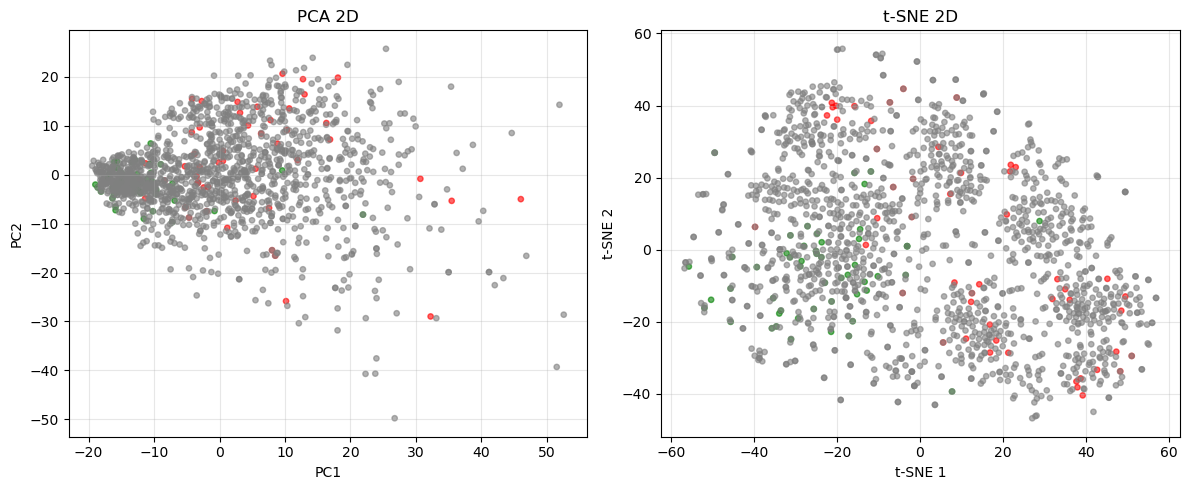

In [15]:
color_map = {
    'cancer': 'red',
    'normal': 'green',
    'sans_label': 'gray'
}
point_colors = metadata['label'].map(color_map).fillna('blue')

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(features_pca_2d[:, 0], features_pca_2d[:, 1], c=point_colors, alpha=0.6, s=15)
axes[0].set_title('PCA 2D')
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')
axes[0].grid(True, alpha=0.3)

axes[1].scatter(features_tsne_2d[:, 0], features_tsne_2d[:, 1], c=point_colors, alpha=0.6, s=15)
axes[1].set_title('t-SNE 2D')
axes[1].set_xlabel('t-SNE 1')
axes[1].set_ylabel('t-SNE 2')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 3. Choix du nombre de clusters

In [16]:
def find_optimal_k(x, max_k=10):
    inertias = []
    silhouette_scores = []
    db_scores = []

    k_values = list(range(2, min(max_k + 1, len(x))))
    for k in k_values:
        model = KMeans(n_clusters=k, random_state=42, n_init=10)
        labels = model.fit_predict(x)
        inertias.append(model.inertia_)
        silhouette_scores.append(silhouette_score(x, labels))
        db_scores.append(davies_bouldin_score(x, labels))

    return k_values, inertias, silhouette_scores, db_scores

k_values, inertias, silhouette_scores, db_scores = find_optimal_k(features_pca_clustering, max_k=10)

# Choix principal : silhouette max
optimal_k = k_values[int(np.argmax(silhouette_scores))]

print('optimal_k =', optimal_k)

results_k = pd.DataFrame({
    'k': k_values,
    'inertia': inertias,
    'silhouette_score': silhouette_scores,
    'davies_bouldin_score': db_scores
})
display(results_k)

optimal_k = 2


,k,inertia,silhouette_score,davies_bouldin_score
0,2,1.266708e+06,0.154417,2.569336
1,3,1.193129e+06,0.099623,2.878191
2,4,1.139888e+06,0.113031,2.640531
3,5,1.094714e+06,0.133109,2.537596
4,6,1.062580e+06,0.085732,2.562849
5,7,1.032856e+06,0.090024,2.641868
6,8,1.008015e+06,0.095993,2.614320
7,9,9.863379e+05,0.099799,2.514683
8,10,9.620312e+05,0.098316,2.400824


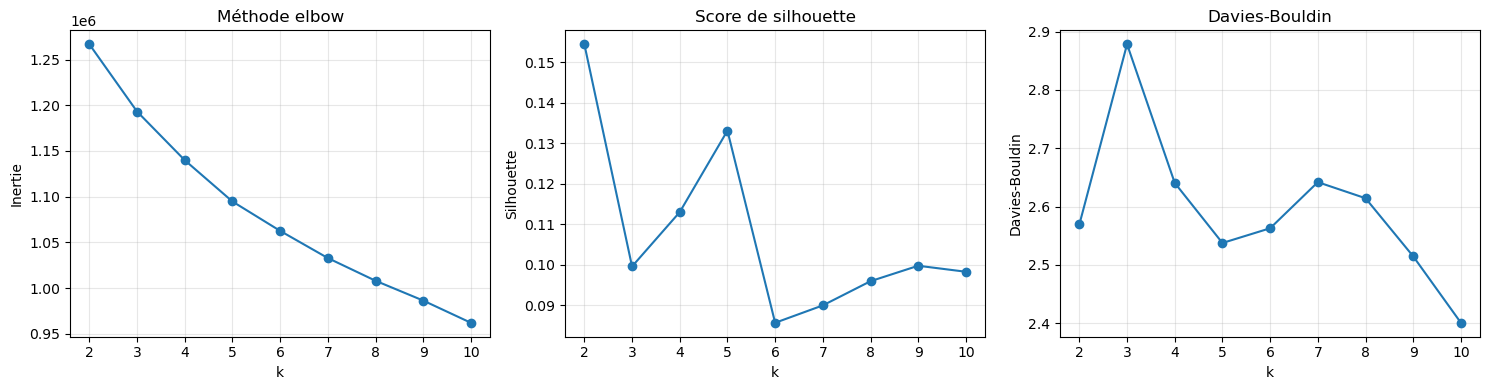

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(k_values, inertias, 'o-')
axes[0].set_title('Méthode elbow')
axes[0].set_xlabel('k')
axes[0].set_ylabel('Inertie')
axes[0].grid(True, alpha=0.3)

axes[1].plot(k_values, silhouette_scores, 'o-')
axes[1].set_title('Score de silhouette')
axes[1].set_xlabel('k')
axes[1].set_ylabel('Silhouette')
axes[1].grid(True, alpha=0.3)

axes[2].plot(k_values, db_scores, 'o-')
axes[2].set_title('Davies-Bouldin')
axes[2].set_xlabel('k')
axes[2].set_ylabel('Davies-Bouldin')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 4. Dendrogramme

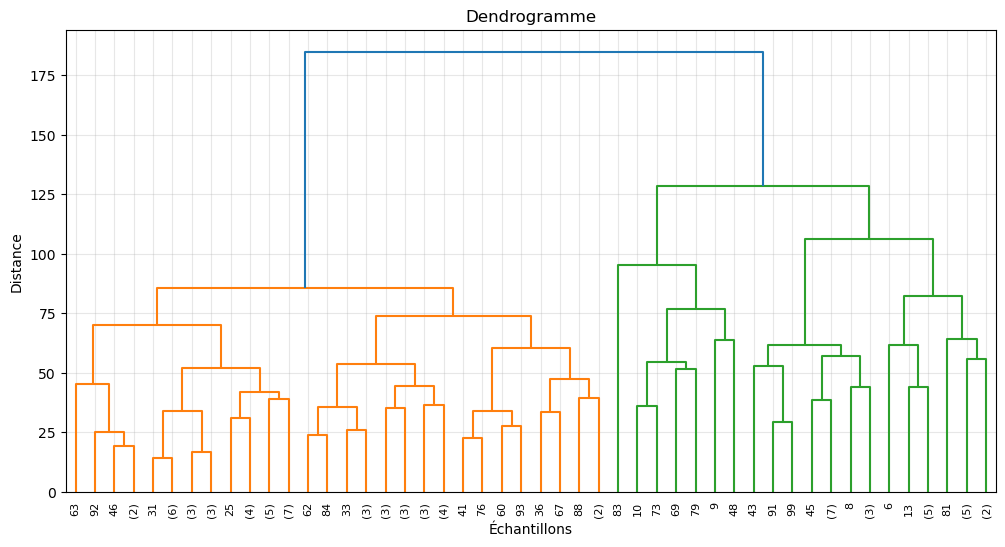

In [18]:
sample_size = min(100, len(features_pca_clustering))
np.random.seed(42)
sample_idx = np.random.choice(len(features_pca_clustering), sample_size, replace=False)

linkage_matrix = linkage(features_pca_clustering[sample_idx], method='ward')

plt.figure(figsize=(12, 6))
dendrogram(linkage_matrix, truncate_mode='level', p=5)
plt.title('Dendrogramme')
plt.xlabel("Échantillons")
plt.ylabel("Distance")
plt.grid(True, alpha=0.3)
plt.show()

## 5. Application des algorithmes de clustering

In [19]:
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(features_pca_clustering)

hierarchical = AgglomerativeClustering(n_clusters=optimal_k)
hierarchical_labels = hierarchical.fit_predict(features_pca_clustering)

# DBSCAN reste exploratoire, paramètres à ajuster si besoin
dbscan = DBSCAN(eps=8.0, min_samples=10)
dbscan_labels = dbscan.fit_predict(features_pca_clustering)

print('K-Means      :', len(np.unique(kmeans_labels)), 'clusters')
print('Hierarchical :', len(np.unique(hierarchical_labels)), 'clusters')
print('DBSCAN       :', len(np.unique(dbscan_labels)), 'clusters')
print('DBSCAN outliers :', int(np.sum(dbscan_labels == -1)))

K-Means      : 2 clusters
Hierarchical : 2 clusters
DBSCAN       : 3 clusters
DBSCAN outliers : 1471


In [20]:
def evaluate_clustering_quality(x_all, labels_all, labeled_indices=None, y_true=None):
    metrics = {}

    if len(np.unique(labels_all)) > 1:
        metrics['silhouette_score'] = float(silhouette_score(x_all, labels_all))
        metrics['davies_bouldin_score'] = float(davies_bouldin_score(x_all, labels_all))

    if labeled_indices is not None and y_true is not None:
        labeled_cluster_labels = labels_all[labeled_indices]
        if len(np.unique(labeled_cluster_labels)) > 1:
            metrics['adjusted_rand_score'] = float(
                adjusted_rand_score(y_true, labeled_cluster_labels)
            )

    return metrics

kmeans_metrics = evaluate_clustering_quality(
    features_pca_clustering, kmeans_labels, labeled_indices, true_labels
)
hierarchical_metrics = evaluate_clustering_quality(
    features_pca_clustering, hierarchical_labels, labeled_indices, true_labels
)
dbscan_metrics = evaluate_clustering_quality(
    features_pca_clustering, dbscan_labels, labeled_indices, true_labels
)

print('K-Means metrics      :', kmeans_metrics)
print('Hierarchical metrics :', hierarchical_metrics)
print('DBSCAN metrics       :', dbscan_metrics)

K-Means metrics      : {'silhouette_score': 0.1544169932603836, 'davies_bouldin_score': 2.569336456058433, 'adjusted_rand_score': 0.24370826390048933}
Hierarchical metrics : {'silhouette_score': 0.10700433701276779, 'davies_bouldin_score': 2.5641339919060724, 'adjusted_rand_score': 0.48505024049347056}
DBSCAN metrics       : {'silhouette_score': -0.18617579340934753, 'davies_bouldin_score': 1.639063414405278, 'adjusted_rand_score': 0.000808721249959564}


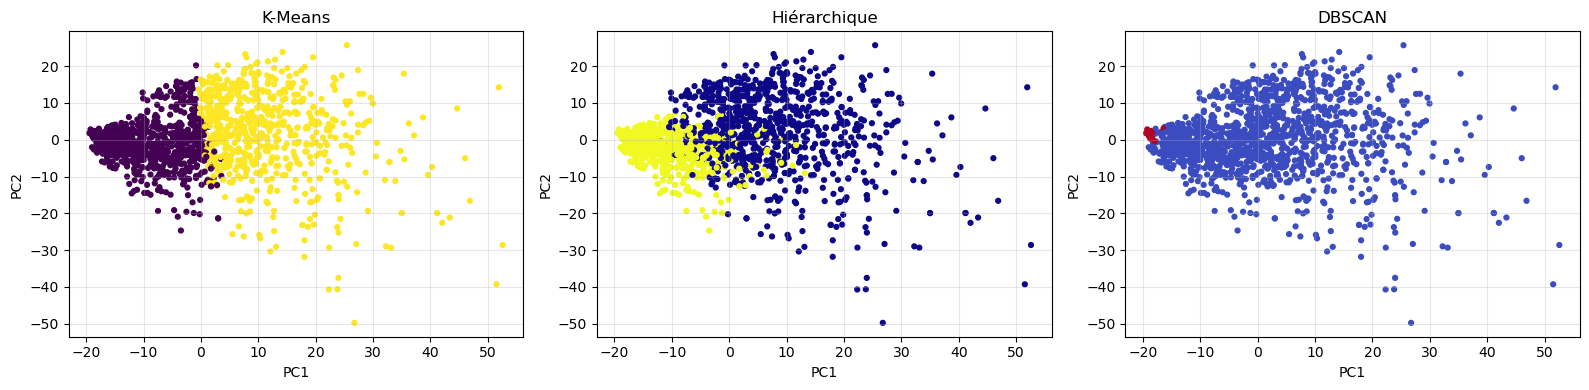

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].scatter(features_pca_2d[:, 0], features_pca_2d[:, 1], c=kmeans_labels, cmap='viridis', s=12)
axes[0].set_title('K-Means')

axes[1].scatter(features_pca_2d[:, 0], features_pca_2d[:, 1], c=hierarchical_labels, cmap='plasma', s=12)
axes[1].set_title('Hiérarchique')

axes[2].scatter(features_pca_2d[:, 0], features_pca_2d[:, 1], c=dbscan_labels, cmap='coolwarm', s=12)
axes[2].set_title('DBSCAN')

for ax in axes:
    ax.set_xlabel('PC1')
    ax.set_ylabel('PC2')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 6. Génération des labels faibles

In [22]:
weak_labels = kmeans_labels

weak_labels_path = PROCESSED_DIR / 'weak_labels_kmeans.npy'
np.save(weak_labels_path, weak_labels)

analysis_df = metadata.copy()
analysis_df['cluster_kmeans'] = kmeans_labels
analysis_df['cluster_hierarchical'] = hierarchical_labels
analysis_df['cluster_dbscan'] = dbscan_labels
analysis_df['pca_1'] = features_pca_2d[:, 0]
analysis_df['pca_2'] = features_pca_2d[:, 1]
analysis_df['tsne_1'] = features_tsne_2d[:, 0]
analysis_df['tsne_2'] = features_tsne_2d[:, 1]

analysis_csv_path = RESULTS_DIR / 'mri_metadata_clusters_notebook3.csv'
analysis_df.to_csv(analysis_csv_path, index=False)

clustering_results = {
    'algorithm': 'KMeans',
    'n_clusters': int(optimal_k),
    'metrics': kmeans_metrics,
    'hierarchical_metrics': hierarchical_metrics,
    'dbscan_metrics': dbscan_metrics,
    'labels': weak_labels.tolist()
}

clustering_results_path = RESULTS_DIR / 'clustering_results.json'
with open(clustering_results_path, 'w', encoding='utf-8') as f:
    json.dump(clustering_results, f, indent=2, ensure_ascii=False)

print('Labels faibles sauvegardés dans :', weak_labels_path)
print('Résultats sauvegardés dans      :', clustering_results_path)
print('CSV d’analyse sauvegardé dans   :', analysis_csv_path)

Labels faibles sauvegardés dans : ../data/processed/weak_labels_kmeans.npy
Résultats sauvegardés dans      : ../results/clustering_results.json
CSV d’analyse sauvegardé dans   : ../results/mri_metadata_clusters_notebook3.csv


In [23]:
labeled_df = analysis_df[analysis_df["label"].isin(["cancer", "normal"])]

pd.crosstab(
    labeled_df["cluster_kmeans"],
    labeled_df["label"],
    normalize="index"
)

label,cancer,normal
cluster_kmeans,,
0,0.323944,0.676056
1,0.931034,0.068966


In [24]:
pd.crosstab(
    labeled_df["cluster_hierarchical"],
    labeled_df["label"],
    normalize="index"
)


label,cancer,normal
cluster_hierarchical,,
0,0.948718,0.051282
1,0.213115,0.786885


In [25]:
print("Effectifs :")
display(pd.crosstab(
    labeled_df["cluster_kmeans"],
    labeled_df["label"]
))

print("\nProportions :")
display(pd.crosstab(
    labeled_df["cluster_kmeans"],
    labeled_df["label"],
    normalize="index"
))

Effectifs :


label,cancer,normal
cluster_kmeans,,
0,23,48
1,27,2



Proportions :


label,cancer,normal
cluster_kmeans,,
0,0.323944,0.676056
1,0.931034,0.068966


In [26]:
print("Effectifs :")
display(pd.crosstab(
    labeled_df["cluster_hierarchical"],
    labeled_df["label"]
))

print("\nProportions :")
display(pd.crosstab(
    labeled_df["cluster_hierarchical"],
    labeled_df["label"],
    normalize="index"
))

Effectifs :


label,cancer,normal
cluster_hierarchical,,
0,37,2
1,13,48



Proportions :


label,cancer,normal
cluster_hierarchical,,
0,0.948718,0.051282
1,0.213115,0.786885


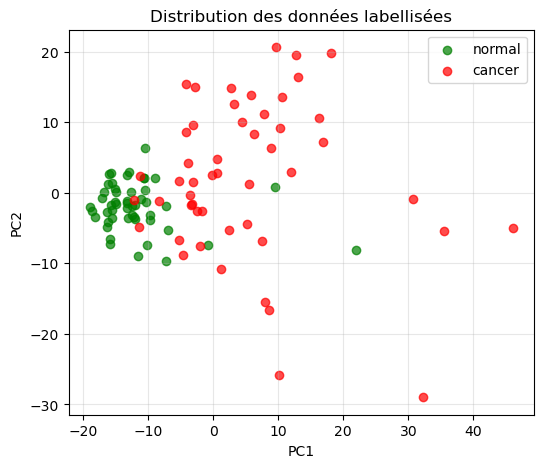

In [27]:
plt.figure(figsize=(6,5))

for label, color in [('normal','green'), ('cancer','red')]:
    idx = labeled_df['label'] == label
    plt.scatter(
        labeled_df.loc[idx,'pca_1'],
        labeled_df.loc[idx,'pca_2'],
        c=color,
        label=label,
        alpha=0.7
    )

plt.legend()
plt.title("Distribution des données labellisées")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.grid(True, alpha=0.3)
plt.show()

In [28]:
cluster_map = (
    labeled_df
    .groupby("cluster_hierarchical")["label"]
    .agg(lambda x: x.value_counts().idxmax())
)

cluster_map


cluster_hierarchical
0    cancer
1    normal
Name: label, dtype: object

In [29]:
analysis_df["weak_label"] = analysis_df["cluster_hierarchical"].map(cluster_map)


In [30]:
analysis_df["weak_label"] = analysis_df["cluster_hierarchical"].map(cluster_map)
analysis_df.to_csv(analysis_csv_path, index=False)